In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.utils import to_categorical
from keras.optimizers import Adam
from keras.regularizers import l2
import matplotlib.pyplot as plt


In [3]:
BASE_DATA_PATH = "paste your dataset path here"


In [4]:
def load_data(data_dir, target_size=(250, 250)):
    data = []
    labels = []

    categories = os.listdir(data_dir)

    for category in categories:
        category_dir = os.path.join(data_dir, category)
        label = 1 if category.lower() == 'fire' else 0

        for img_file in os.listdir(category_dir):
            img_path = os.path.join(category_dir, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, target_size)
            img = img.astype('float32') / 255.0
            data.append(img)
            labels.append(label)

    return np.array(data), np.array(labels)

# Load training data
train_data, train_labels = load_data(os.path.join(BASE_DATA_PATH, 'Training'))


In [6]:
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.2, random_state=42
)

train_labels = to_categorical(train_labels, num_classes=2)
val_labels = to_categorical(val_labels, num_classes=2)

print("Train data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)


Train data shape: (1216, 250, 250, 3)
Validation data shape: (304, 250, 250, 3)


In [7]:
input_shape = (250, 250, 3)
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), strides=(2, 2), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.25))
model.add(Dense(2, activation='softmax'))

optimizer = Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 248, 248, 32)      896       
                                                                 
 batch_normalization_5 (Bat  (None, 248, 248, 32)      128       
 chNormalization)                                                
                                                                 
 conv2d_6 (Conv2D)           (None, 123, 123, 64)      18496     
                                                                 
 batch_normalization_6 (Bat  (None, 123, 123, 64)      256       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 61, 61, 64)        0         
 g2D)                                                            
                                                      

In [8]:
history = model.fit(
    train_data, train_labels,
    epochs=25,
    batch_size=32,
    validation_data=(val_data, val_labels)
)


Epoch 1/25
38/38 [==============================] - 126s 3s/step - loss: 0.9856 - accuracy: 0.8923 - val_loss: 1.1701 - val_accuracy: 0.5164
Epoch 2/25
38/38 [==============================] - 120s 3s/step - loss: 0.6349 - accuracy: 0.9572 - val_loss: 1.1913 - val_accuracy: 0.4836
Epoch 3/25
38/38 [==============================] - 121s 3s/step - loss: 0.5789 - accuracy: 0.9671 - val_loss: 1.1871 - val_accuracy: 0.4836
Epoch 4/25
38/38 [==============================] - 124s 3s/step - loss: 0.5532 - accuracy: 0.9770 - val_loss: 1.0771 - val_accuracy: 0.6086
Epoch 5/25
38/38 [==============================] - 118s 3s/step - loss: 0.5555 - accuracy: 0.9704 - val_loss: 1.0031 - val_accuracy: 0.7303
Epoch 6/25
38/38 [==============================] - 118s 3s/step - loss: 0.5322 - accuracy: 0.9778 - val_loss: 0.8242 - val_accuracy: 0.9013
Epoch 7/25
38/38 [==============================] - 128s 3s/step - loss: 0.5193 - accuracy: 0.9803 - val_loss: 0.6954 - val_accuracy: 0.9276
Epoch 8/25
38

In [9]:
score = model.evaluate(val_data, val_labels, verbose=1)
print("Validation Loss:", score[0])
print("Validation Accuracy:", score[1])


10/10 [==============================] - 7s 652ms/step - loss: 0.5410 - accuracy: 0.9572
Validation Loss: 0.5410481095314026
Validation Accuracy: 0.9572368264198303


In [10]:
def load_test_data(data_dir, target_size=(250, 250)):
    data = []
    labels = []

    for img_file in os.listdir(data_dir):
        img_path = os.path.join(data_dir, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, target_size)
        img = img.astype('float32') / 255.0
        data.append(img)

        # Label from filename
        label = 1 if img_file.lower().startswith('fire') else 0
        labels.append(label)

    return np.array(data), np.array(labels)

test_data, test_labels = load_test_data(os.path.join(BASE_DATA_PATH, 'Testing'))
test_labels = to_categorical(test_labels, num_classes=2)


In [11]:
score = model.evaluate(test_data, test_labels, verbose=1)
print("Test Loss:", score[0])
print("Test Accuracy:", score[1])


12/12 [==============================] - 8s 652ms/step - loss: 0.5579 - accuracy: 0.9526
Test Loss: 0.5579102635383606
Test Accuracy: 0.9526315927505493


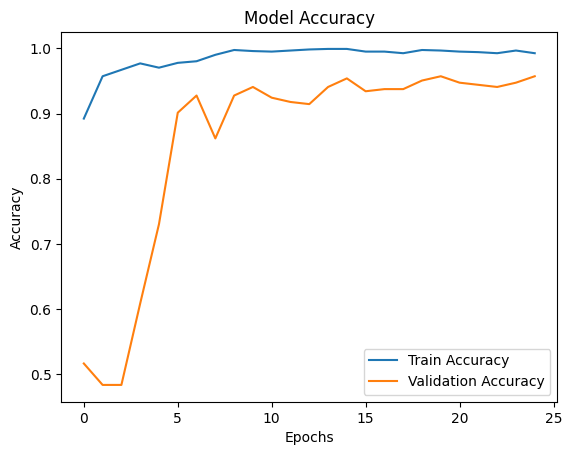

In [12]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

